# Q1 

## Q1 code

1. The text dataset is downloaded from https://www.gutenberg.org/ebooks/145
2. Also, it is 1823 KB, fullfilling the requirement of "at least 1 MB, must be different from the Shakespeare dataset in lecture"

In [1]:
import time
import os
from datetime import datetime
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
from Lecture_17_files.model import GPTConfig, GPT

In [2]:
# Open and read the input file
input_file_path = "Middlemarch.txt"
with open(input_file_path, 'r', encoding='utf-8') as f:
    data = f.read()
print(f"length of dataset in characters: {len(data):,}")

length of dataset in characters: 1,799,375


In [3]:
# get all the unique characters that occur in this text
chars = sorted(list(set(data)))
vocab_size = len(chars)
print("all the unique characters:", ''.join(chars))
print(f"vocab size: {vocab_size:,}")

all the unique characters: 
 !#$%&()*,-./0123456789:;?ABCDEFGHIJKLMNOPQRSTUVWXYZ[]_abcdefghijklmnopqrstuvwxyzàâäæèéêîòôöùûüœ—‘’“”•…™﻿
vocab size: 106


In [4]:
# go through all unique characters 'ch' and assign it an integer index i
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
print("string to integer map: ", stoi)
def encode(s):
    return [stoi[c] for c in s] # encoder: take a string, output a list of i
def decode(l):
    return ''.join([itos[i] for i in l]) # decoder: take a list of integers,
    
# create the train and test splits
n = len(data)
train_data = data[:int(n*0.9)]
val_data = data[int(n*0.9):]

# encode both to integers
train_ids = encode(train_data)
val_ids = encode(val_data)
print(f"train has {len(train_ids):,} tokens")
print(f"val has {len(val_ids):,} tokens")

train_ids = np.array(train_ids, dtype=np.uint16)
val_ids = np.array(val_ids, dtype=np.uint16)

string to integer map:  {'\n': 0, ' ': 1, '!': 2, '#': 3, '$': 4, '%': 5, '&': 6, '(': 7, ')': 8, '*': 9, ',': 10, '-': 11, '.': 12, '/': 13, '0': 14, '1': 15, '2': 16, '3': 17, '4': 18, '5': 19, '6': 20, '7': 21, '8': 22, '9': 23, ':': 24, ';': 25, '?': 26, 'A': 27, 'B': 28, 'C': 29, 'D': 30, 'E': 31, 'F': 32, 'G': 33, 'H': 34, 'I': 35, 'J': 36, 'K': 37, 'L': 38, 'M': 39, 'N': 40, 'O': 41, 'P': 42, 'Q': 43, 'R': 44, 'S': 45, 'T': 46, 'U': 47, 'V': 48, 'W': 49, 'X': 50, 'Y': 51, 'Z': 52, '[': 53, ']': 54, '_': 55, 'a': 56, 'b': 57, 'c': 58, 'd': 59, 'e': 60, 'f': 61, 'g': 62, 'h': 63, 'i': 64, 'j': 65, 'k': 66, 'l': 67, 'm': 68, 'n': 69, 'o': 70, 'p': 71, 'q': 72, 'r': 73, 's': 74, 't': 75, 'u': 76, 'v': 77, 'w': 78, 'x': 79, 'y': 80, 'z': 81, 'à': 82, 'â': 83, 'ä': 84, 'æ': 85, 'è': 86, 'é': 87, 'ê': 88, 'î': 89, 'ò': 90, 'ô': 91, 'ö': 92, 'ù': 93, 'û': 94, 'ü': 95, 'œ': 96, '—': 97, '‘': 98, '’': 99, '“': 100, '”': 101, '•': 102, '…': 103, '™': 104, '\ufeff': 105}
train has 1,619,437

In [5]:
device_type = "cpu"
device = torch.device("cpu")

class TextDataset(Dataset):
    def __init__(self, text_ids, block_size):
        self.data = text_ids.astype(np.int64)
        self.block_size = block_size

    def __len__(self):
        # number of possible sequences
        return len(self.data) - self.block_size

    def __getitem__(self, idx):
        # x: tokens i .. i+block_size-1
        # y: tokens i+1 .. i+block_size
        chunk = self.data[idx : idx + self.block_size + 1]
        x = torch.from_numpy(chunk[:-1])
        y = torch.from_numpy(chunk[1:])
        return x, y
        
# Define a function for training 3 sets of hyperparameters
def train(block_size, n_layer, n_head, n_embd, name):
    print(f"\n{name}")
    print("hyperparams:",f"block_size={block_size}, n_layer={n_layer}, n_head={n_head}, n_embd={n_embd}")

    # Main training loop
    batch_size = 12
    train_dataset = TextDataset(train_ids, block_size)
    validate_dataset = TextDataset(val_ids, block_size)
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    validate_dataloader = DataLoader(validate_dataset, batch_size=batch_size, shuffle=False, drop_last=True)

    model_args = dict(
        n_layer = n_layer,
        n_head = n_head,
        n_embd = n_embd,
        block_size = block_size,
        bias = True,
        vocab_size = 106,  
        dropout = 0.0,
    )
    gptconf = GPTConfig(**model_args)
    model = GPT(gptconf).to(device)
    print(model_args)


    learning_rate = 0.001
    beta1 = 0.9
    beta2 = 0.99
    weight_decay = 0.1

    param_dict = {pn: p for pn, p in model.named_parameters() if p.requires_grad}
    decay_params   = [p for n, p in param_dict.items() if p.dim() >= 2]
    nodecay_params = [p for n, p in param_dict.items() if p.dim() <  2]

    optim_groups = [
        {'params': decay_params, 'weight_decay': weight_decay},
        {'params': nodecay_params, 'weight_decay': 0.0}
    ]

    optimizer = torch.optim.AdamW(optim_groups, lr=learning_rate, betas=(beta1, beta2))

    warmup_iters = 100
    lr_decay_iters = 2000   
    min_lr = 1e-4

    warmup = LinearLR(
        optimizer,
        start_factor=0.01,
        end_factor=1.0,
        total_iters=warmup_iters
    )

    cosine_decay = CosineAnnealingLR(
        optimizer,
        T_max=lr_decay_iters - warmup_iters,
        eta_min=min_lr
    )

    scheduler = SequentialLR(
        optimizer,
        schedulers=[warmup, cosine_decay],
        milestones=[warmup_iters]
    )
    
    # Main training loop
    max_iter = 2000
    eval_interval = 100
    eval_iters = 20

    best_val_loss = 100.0
    iter_counter = 0
    validation_losses = []
    train_losses = []
    tmp_train_loss = 0.0

    os.makedirs("./Lecture_17_files", exist_ok=True)
    current_datetime = datetime.now().strftime("%Y%m%d_%H%M%S")

    model.train()
    while iter_counter < max_iter:
        for X, Y in train_dataloader:
            X = X.to(device)
            Y = Y.to(device)
            
            if iter_counter % eval_interval == 0 and iter_counter > 0:
                model.eval()
                validation_loss = 0.0
                eval_counter = 0

                with torch.no_grad():
                    for X_val, Y_val in validate_dataloader:
                        X_val = X_val.to(device)
                        Y_val = Y_val.to(device)
                        logits, loss = model(X_val, Y_val)
                        validation_loss += loss.item()
                        eval_counter += 1
                        if eval_counter >= eval_iters:
                            break

                validation_losses.append(validation_loss / eval_iters)
                train_losses.append(tmp_train_loss / eval_interval)
                tmp_train_loss = 0.0

                print(f"step {iter_counter}: train loss {train_losses[-1]:.4f}, "
                      f"validation loss {validation_losses[-1]:.4f}")

                if validation_losses[-1] < best_val_loss:
                    print("new best validation loss, saving checkpoint")
                    ckpt_path = os.path.join("./Lecture_17_files/",
                                             f"best_model_{name}_{current_datetime}.pt")
                    torch.save(model.state_dict(), ckpt_path)
                    best_val_loss = validation_losses[-1]

                model.train()

            logits, loss = model(X, Y)
            tmp_train_loss += loss.item()

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            scheduler.step()

            iter_counter += 1
            if iter_counter >= max_iter:
                break

    model.eval()
    with torch.no_grad():
        start = torch.zeros((1, 1), dtype=torch.long, device=device)  
        out_ids = model.generate(start, max_new_tokens=200)[0].cpu().tolist()
    text = decode(out_ids)

    print(f"\n Generated text ({name})\n")
    print(text)  
    print("\n \n")

    return model_args, text

configs = [
    ("small", 64,  4, 4, 128),
    ("medium", 128, 6, 8, 256),
    ("large", 256, 8, 8, 512),
]

all_results = []
for name, block_size, n_layer, n_head, n_embd in configs:
    args, text = train(block_size, n_layer, n_head, n_embd, name=name)
    all_results.append((args, text))


small
hyperparams: block_size=64, n_layer=4, n_head=4, n_embd=128
number of parameters: 0.81M
{'n_layer': 4, 'n_head': 4, 'n_embd': 128, 'block_size': 64, 'bias': True, 'vocab_size': 106, 'dropout': 0.0}


C:\Users\yiyin\anaconda3\envs\mlhw\lib\site-packages\torch\optim\lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


step 100: train loss 3.2644, validation loss 2.5548
new best validation loss, saving checkpoint
step 200: train loss 2.5625, validation loss 2.4281
new best validation loss, saving checkpoint
step 300: train loss 2.4586, validation loss 2.2990
new best validation loss, saving checkpoint
step 400: train loss 2.3442, validation loss 2.2771
new best validation loss, saving checkpoint
step 500: train loss 2.2366, validation loss 2.1387
new best validation loss, saving checkpoint
step 600: train loss 2.1531, validation loss 2.0425
new best validation loss, saving checkpoint
step 700: train loss 2.0729, validation loss 1.9964
new best validation loss, saving checkpoint
step 800: train loss 2.0178, validation loss 1.9413
new best validation loss, saving checkpoint
step 900: train loss 1.9806, validation loss 1.8848
new best validation loss, saving checkpoint
step 1000: train loss 1.9344, validation loss 1.8898
step 1100: train loss 1.9037, validation loss 1.8134
new best validation loss, savi

# Q2

## The code is copied from `HW7Q2_starter.ipynb`

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, utils
from sklearn.model_selection import train_test_split

print("TensorFlow version:", tf.__version__)

# Load dataset
(x_train_full, y_train_full), (x_test, y_test) = datasets.fashion_mnist.load_data()

# Normalize images
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Expand dims
x_train_full = x_train_full[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

# One-hot encode
y_train_full = utils.to_categorical(y_train_full, 10)
y_test = utils.to_categorical(y_test, 10)

# Split train into train/val (90/10)
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.1, random_state=42
)

print(f"Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_test.shape}")

TensorFlow version: 2.16.2
Train: (54000, 28, 28, 1), Val: (6000, 28, 28, 1), Test: (10000, 28, 28, 1)


## Q2-1 code

### My code starts from this

### Reference:
1.https://stackoverflow.com/questions/48355700/dropout-behavior-in-keras-with-rate-1-dropping-all-input-units-not-as-expected


In [2]:
from tensorflow import keras
model=keras.Sequential([
    keras.Input(shape=(28,28,1)),
    keras.layers.Conv2D(32,(3,3),activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(64,(3,3),activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         102,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
model.compile(
    optimizer = keras.optimizers.SGD(learning_rate=0.02),
    loss='categorical_crossentropy',           
    metrics=[keras.metrics.CategoricalAccuracy()]
            )

model.fit(x_train, y_train, 
          epochs=10,
          batch_size=64,
          validation_data=(x_val, y_val),
          verbose=2
         )

Epoch 1/10
844/844 - 8s - 9ms/step - categorical_accuracy: 0.6533 - loss: 0.9486 - val_categorical_accuracy: 0.7718 - val_loss: 0.6237
Epoch 2/10
844/844 - 8s - 9ms/step - categorical_accuracy: 0.7859 - loss: 0.5698 - val_categorical_accuracy: 0.8132 - val_loss: 0.4991
Epoch 3/10
844/844 - 8s - 9ms/step - categorical_accuracy: 0.8159 - loss: 0.4973 - val_categorical_accuracy: 0.8265 - val_loss: 0.4597
Epoch 4/10
844/844 - 7s - 9ms/step - categorical_accuracy: 0.8316 - loss: 0.4582 - val_categorical_accuracy: 0.8475 - val_loss: 0.4174
Epoch 5/10
844/844 - 8s - 9ms/step - categorical_accuracy: 0.8466 - loss: 0.4259 - val_categorical_accuracy: 0.8577 - val_loss: 0.3916
Epoch 6/10
844/844 - 8s - 9ms/step - categorical_accuracy: 0.8541 - loss: 0.4026 - val_categorical_accuracy: 0.8527 - val_loss: 0.3924
Epoch 7/10
844/844 - 8s - 9ms/step - categorical_accuracy: 0.8604 - loss: 0.3852 - val_categorical_accuracy: 0.8668 - val_loss: 0.3632
Epoch 8/10
844/844 - 8s - 9ms/step - categorical_accura

In [4]:
model.evaluate(x_test,y_test, verbose = 2)

313/313 - 1s - 3ms/step - categorical_accuracy: 0.8747 - loss: 0.3504


[0.3504418730735779, 0.8747000098228455]

## Q2-2 code

In [5]:
import datetime
log_dir = "hw7_log/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
model.fit(x=x_train, y=y_train, 
          epochs=10,
          verbose = 2,
          batch_size=64,
          validation_data=(x_val, y_val), 
          callbacks=[tensorboard_callback])

Epoch 1/10
844/844 - 8s - 10ms/step - categorical_accuracy: 0.8772 - loss: 0.3372 - val_categorical_accuracy: 0.8800 - val_loss: 0.3216
Epoch 2/10
844/844 - 8s - 10ms/step - categorical_accuracy: 0.8787 - loss: 0.3298 - val_categorical_accuracy: 0.8678 - val_loss: 0.3472
Epoch 3/10
844/844 - 8s - 10ms/step - categorical_accuracy: 0.8821 - loss: 0.3221 - val_categorical_accuracy: 0.8828 - val_loss: 0.3211
Epoch 4/10
844/844 - 8s - 10ms/step - categorical_accuracy: 0.8861 - loss: 0.3121 - val_categorical_accuracy: 0.8802 - val_loss: 0.3233
Epoch 5/10
844/844 - 8s - 10ms/step - categorical_accuracy: 0.8874 - loss: 0.3071 - val_categorical_accuracy: 0.8862 - val_loss: 0.3102
Epoch 6/10
844/844 - 8s - 10ms/step - categorical_accuracy: 0.8908 - loss: 0.3012 - val_categorical_accuracy: 0.8918 - val_loss: 0.2984
Epoch 7/10
844/844 - 8s - 10ms/step - categorical_accuracy: 0.8927 - loss: 0.2944 - val_categorical_accuracy: 0.8950 - val_loss: 0.2887
Epoch 8/10
844/844 - 8s - 10ms/step - categorica

## Q2-2 output

The accuracy for both training and validation refer to `q2_2_1.png`
The loss for both training and validation refer to `q2_2_2.png`.

# Q3

## The code is copied from `HW7Q3_starter.ipynb`

In [9]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

print("JAX version:", jax.__version__)

# DO NOT MODIFY THE CONTENTS OF THIS CELL

# Simulation parameters
num_steps=200 # total number of simulation steps
dt=0.05 # time step size
g=9.8 # gravity acceleration constant
bounce=0.8 # bounce energy retention factor

def step(state):
    """
    One physics step for a bouncing ball.
    Args:
        state: jnp.array([x, y, vx, vy])
    Returns:
        new_state: jnp.array([x_new, y_new, vx_new, vy_new])
    """
    x, y, vx, vy = state

    # integrate
    x_new = x + vx * dt
    y_new = y + vy * dt - 0.5 * g * dt**2
    vx_new = vx
    vy_new = vy - g * dt # gravity effect

    # bounce condition 
    bounced = y_new < 0 # next y position below ground (<0.0)
    y_new = jnp.where(bounced, 0.0, y_new) # reset y position to ground (0.0)
    vy_new = jnp.where(bounced, -bounce * vy_new, vy_new) # reverse and reduce y velocity
    vx_new = jnp.where(bounced, bounce * vx_new, vx_new) # reduce x velocity

    return jnp.array([x_new, y_new, vx_new, vy_new])


def simulate(init_state):
    """
    Simulate the bouncing ball over time.
    Args:
        init_state: jnp.array([x0, y0, vx0, vy0])
    Returns:
        trajectory: jnp.array of shape (num_steps+1, 4)
    """ 
    def body_fn(state, _):
        new_state = step(state)
        return new_state, new_state  # carry + record

    # Run the simulation using jax.lax.scan
    _, trajectory = jax.lax.scan(body_fn, init_state, None, length=num_steps)
    trajectory = jnp.vstack([init_state, trajectory])  # include initial state
    return trajectory  # shape: (num_steps+1, 4)

def plot_trajectory(traj, title="Bouncing Ball Trajectory"):
    """
    Plot (x, y) positions of the simulated ball.
    Args:
        traj: jnp.array of shape (T, 4)
        target: optional (x_target, y_target) tuple for visualization
    """
    x, y = traj[:, 0], traj[:, 1]

    plt.figure(figsize=(6, 4))
    plt.plot(x, y, label="trajectory")
    plt.axhline(0, color="black", lw=1)
    plt.xlabel("x position")
    plt.ylabel("y position")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

JAX version: 0.4.31


In [16]:
def get_loss(pos_init, pos_target):
    """
    pos_init: 2-dim vector indicating the initial position of the ball `jnp.array([x0, y0])`
    pos_target: 2-dim vector indicating the target position of the ball `jnp.array([x_target, y_target])`
    return: loss_fun(which is related to v_int)
    """
    def loss(v_init):
        init_state = jnp.concatenate([pos_init, v_init])  # shape (4,)
        traj = simulate(init_state)                       # shape (num_steps+1, 4)
        final_pos = traj[-1, :2]                          # how close the final point in the trajectory is to the target point.
        return jnp.average((final_pos - pos_target) ** 2)
    return loss

# Apply jax.jit to get_loss_grad function
def get_loss_grad(pos_init, pos_target):
    loss = get_loss(pos_init, pos_target)
    loss_grad = jax.jit(jax.value_and_grad(loss))
    return loss_grad

lr=0.05
num_epochs = 2000
v_init=jnp.array([5.0, 5.0])

def optimize(pos_init, pos_target,
                              v_init=v_init,
                              lr=lr,
                              num_epochs =num_epochs ):
    """
    pos_init: initial position [x0, y0]
    pos_target: target position [x_target, y_target]
    v_init: initial guess for velocity [vx0, vy0]
    return: optimized_v_init
    """
    loss_grad = get_loss_grad(pos_init, pos_target)

    v = v_init
    for i in range(num_steps):
        loss_val, grad_v = loss_grad(v)
        v = v - lr * grad_v
    return v

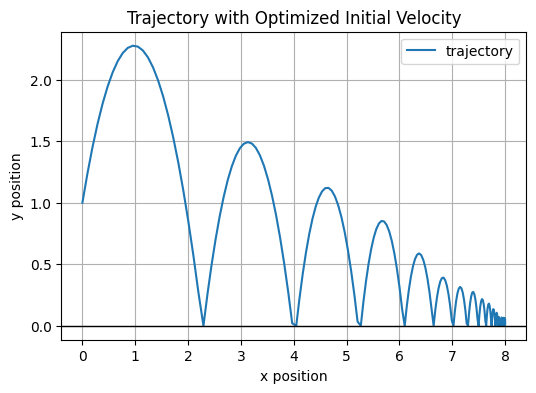

Final position: [7.999998   0.01704491]
Target position: [8. 0.]
optimized_v_init = [1.9089129 5.000477 ]


In [17]:
pos_init = jnp.array([0.0, 1.0])
pos_target = jnp.array([8.0, 0.0])
optimized_v_init = optimize(pos_init, pos_target)
new_init_state = jnp.concatenate([pos_init, optimized_v_init])
traj = simulate(new_init_state)
plot_trajectory(traj, title="Trajectory with Optimized Initial Velocity")
print("Final position:", traj[-1, :2])
print("Target position:", pos_target)
print("optimized_v_init =", optimized_v_init)